## **ICE CREAM SALES DATASET**

In [27]:
import pandas as pd

## **Import the dataset**|

In [28]:
df=pd.read_csv("Ice_cream selling data.csv")
df

,Temperature (°C),Ice Cream Sales (units)
0,-4.662263,41.842986
1,-4.316559,34.661120
2,-4.213985,39.383001
3,-3.949661,37.539845
4,-3.578554,32.284531
5,-3.455712,30.001138
6,-3.108440,22.635401
7,-3.081303,25.365022
8,-2.672461,19.226970
9,-2.652287,20.279679


Here the dataset as continuous numerical values,
we can apply regression 

## **Import the libraries**

In [29]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score 

## **Explore the DATASET**

In [30]:
print(df.info())
print()
print(df.describe())
print()
print(df.duplicated())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 2 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Temperature (°C)         49 non-null     float64
 1   Ice Cream Sales (units)  49 non-null     float64
dtypes: float64(2)
memory usage: 916.0 bytes
None

       Temperature (°C)  Ice Cream Sales (units)
count         49.000000                49.000000
mean           0.271755                15.905308
std            2.697672                12.264682
min           -4.662263                 0.328626
25%           -2.111870                 4.857988
50%            0.688781                12.615181
75%            2.784836                25.142082
max            4.899032                41.842986

0     False
1     False
2     False
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
11    False
12    False
13    False
14    False
15    Fal

## <span style="color: yellow">**OBSERVATION:**</span>
There is no null values

## **Check for missing values**

In [31]:
print(df.isnull().sum())

Temperature (°C)           0
Ice Cream Sales (units)    0
dtype: int64


## **Check for outliers**

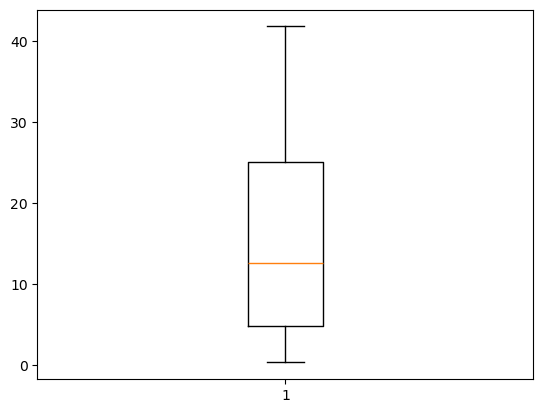

In [32]:
plt.boxplot(df['Ice Cream Sales (units)'])
plt.show()

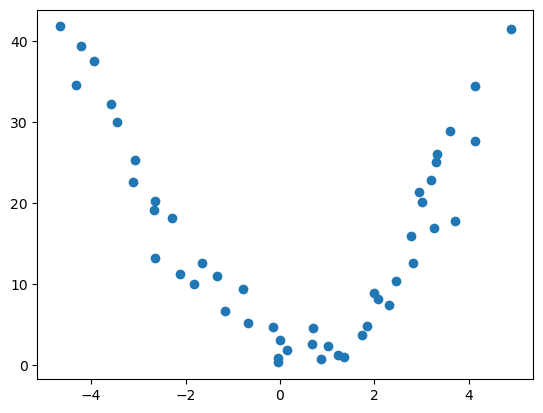

In [33]:
plt.scatter(df[ 'Temperature (°C)'],df['Ice Cream Sales (units)'])

In [34]:
df.corr()

,Temperature (°C),Ice Cream Sales (units)
Temperature (°C),1.000000,-0.175184
Ice Cream Sales (units),-0.175184,1.000000


In [35]:
X=df.drop(columns=['Ice Cream Sales (units)'])
y=df['Ice Cream Sales (units)']

In [36]:
Xtrain,Xtest,ytrain,ytest=train_test_split(X,y,test_size=0.2,random_state=42)

In [37]:
model=LinearRegression()

In [38]:
model.fit(Xtrain,ytrain)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[-1.15]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Temperature (°C)']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,17.14
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


In [39]:
y_pred_train=model.predict(Xtrain)

In [40]:
y_pred_test=model.predict(Xtest)

In [41]:
mae = mean_absolute_error(ytrain, y_pred_train)
print("MAE:", mae)
mse = mean_squared_error(ytrain, y_pred_train)
print("MSE:", mse)
rmse = np.sqrt(mse)
print("RMSE:", rmse)
r2 = r2_score(ytrain, y_pred_train)
print("R2 Score:", r2)

MAE: 10.136398159361041
MSE: 143.33160093981343
RMSE: 11.972117646423854
R2 Score: 0.06579063815950037


In [42]:
mae = mean_absolute_error(ytest, y_pred_test)
print("MAE:", mae)
mse = mean_squared_error(ytest, y_pred_test)
print("MSE:", mse)
rmse = np.sqrt(mse)
print("RMSE:", rmse)
r2 = r2_score(ytest, y_pred_test)
print("R2 Score:", r2)

MAE: 11.752026695440602
MSE: 149.32629119325182
RMSE: 12.219913714640207
R2 Score: -0.5751270190188225
